In [2]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/data_processing
scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [3]:
import sys
sys.path.append('../../utils')
from functions import * 

In [4]:
# load adata object for tabula muris 
adata = sc.read_h5ad("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMarrow/adata.h5ad")

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Let's do some quick QC of the raw counts from featureCounts

In [5]:
# Remove genes from adata that have "ERCC" in their name, these are just spike ins 
adata = adata[:, [not x.startswith('ERCC') for x in adata.var_names]]
# Also remove transgenes, any gene name that ends in "_transgene"
adata = adata[:, [not x.endswith('_transgene') for x in adata.var_names]]
# Also remove "LOC" genes for now, any gene name that starts with "LOC"
adata = adata[:, [not x.startswith('LOC') for x in adata.var_names]]
# Also remove recombinant protiens, gene names that start with MGC
adata = adata[:, [not x.startswith('MGC') for x in adata.var_names]]
# Also remove polyclonal antibodies? gene names that end in Rik 
adata = adata[:, [not x.endswith('Rik') for x in adata.var_names]]

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:170: FutureWarning: X.dtype being converted to np.float32 from int64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  view_to_actual(adata)


normalizing counts per cell
    finished (0:00:00)


/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


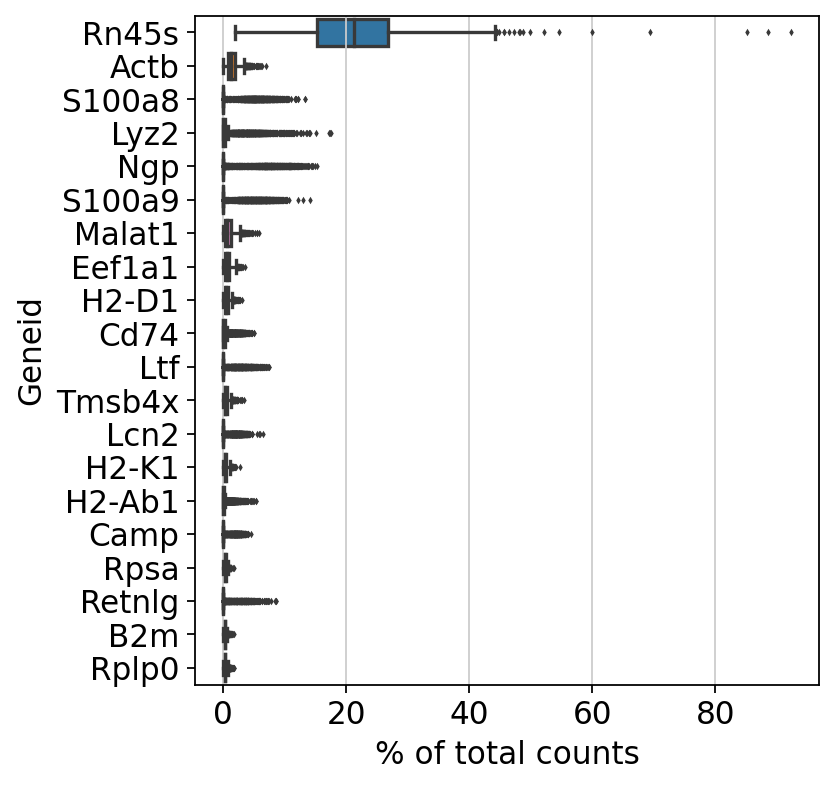

In [6]:
sc.pl.highest_expr_genes(adata, n_top=20, )

In [7]:
# Start with very basic filtering 
print('Started with: \n', adata)
print_separator()
sc.pp.filter_cells(adata, min_genes=200) # remove cells that have less than 200 genes expressed
sc.pp.filter_genes(adata, min_cells=5) # remove genes that are expressed in less than 3 cells
print('Finished with: \n', adata)

Started with: 
 AnnData object with n_obs × n_vars = 4927 × 20992
    obs: 'cell_ontology_class', 'mouse.id', 'subtissue', 'tissue', 'cell_type', 'cell_id'
    var: 'gene_name'
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
filtered out 5067 genes that are detected in less than 5 cells
Finished with: 
 AnnData object with n_obs × n_vars = 4927 × 15925
    obs: 'cell_ontology_class', 'mouse.id', 'subtissue', 'tissue', 'cell_type', 'cell_id', 'n_genes'
    var: 'gene_name', 'n_cells'


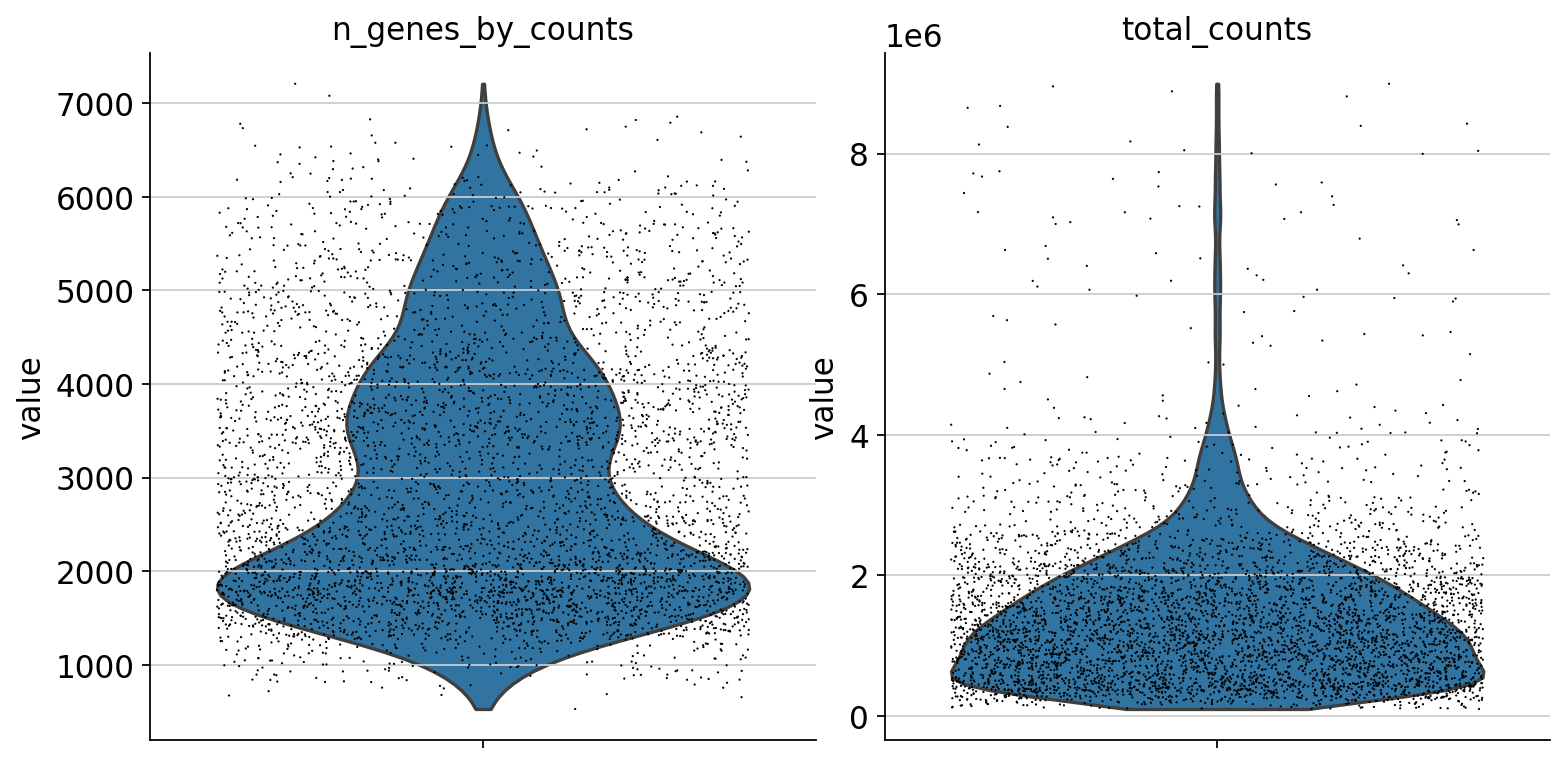

In [8]:
# With pp.calculate_qc_metrics, we can compute many metrics very efficiently.
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'],
             jitter=0.4, multi_panel=True)

# n_genes_by_counts represents the number of genes that are detected (expressed) in a particular cell after applying a count threshold. 
# total_counts represents the total number of RNA molecules (total count) detected in a given cell.

# For example, cells with extremely low total_counts might be low-quality cells, and cells with very high total_counts 
# might be doublets (two cells that were sequenced together, leading to inflated transcript counts). 

Remove cells with very high values for total_counts, possible doublets
Started with: 
 AnnData object with n_obs × n_vars = 4927 × 15925
    obs: 'cell_ontology_class', 'mouse.id', 'subtissue', 'tissue', 'cell_type', 'cell_id', 'n_genes', 'n_genes_by_counts', 'total_counts'
    var: 'gene_name', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Finished with: 
 View of AnnData object with n_obs × n_vars = 4850 × 15925
    obs: 'cell_ontology_class', 'mouse.id', 'subtissue', 'tissue', 'cell_type', 'cell_id', 'n_genes', 'n_genes_by_counts', 'total_counts'
    var: 'gene_name', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'


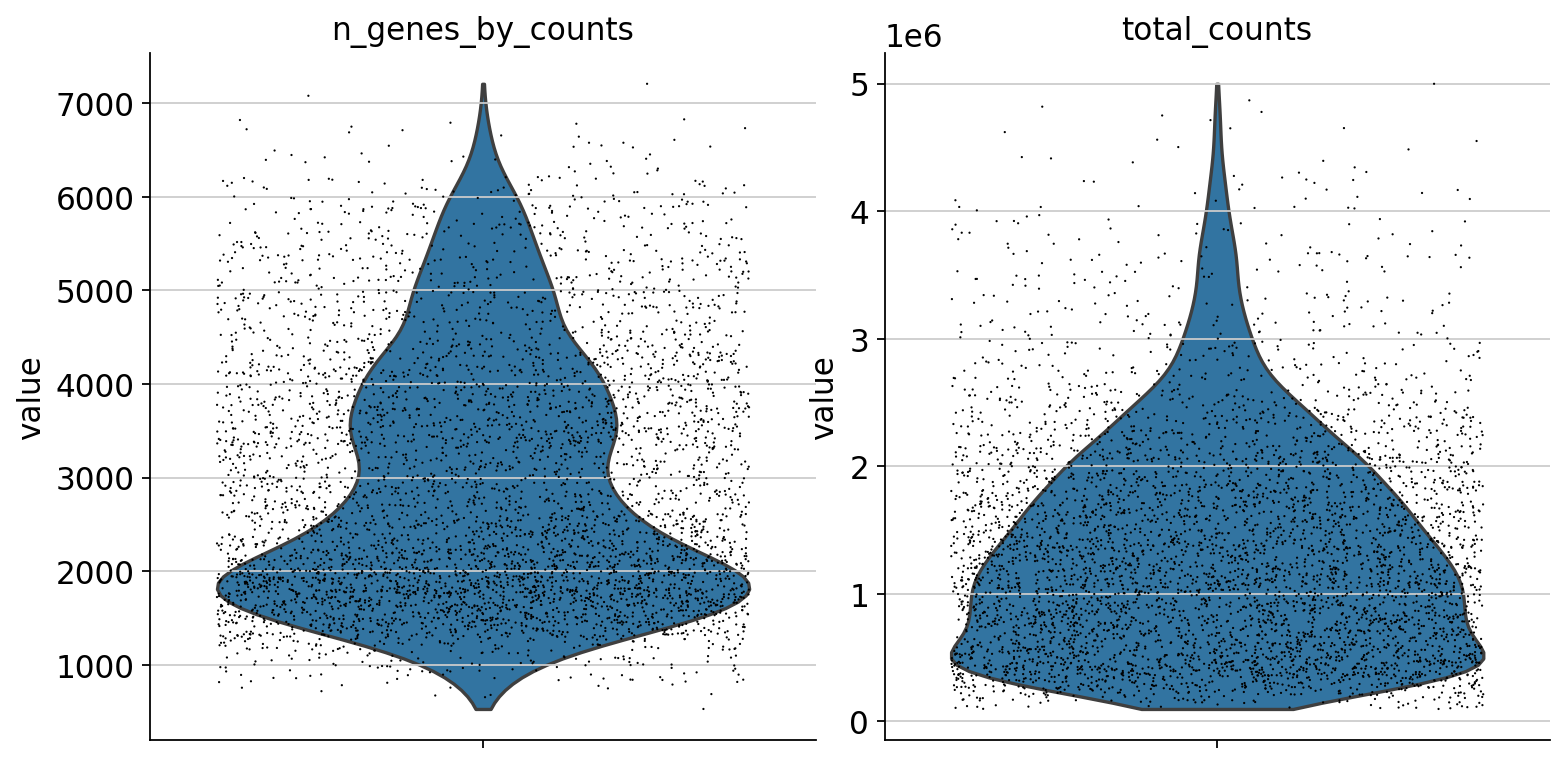

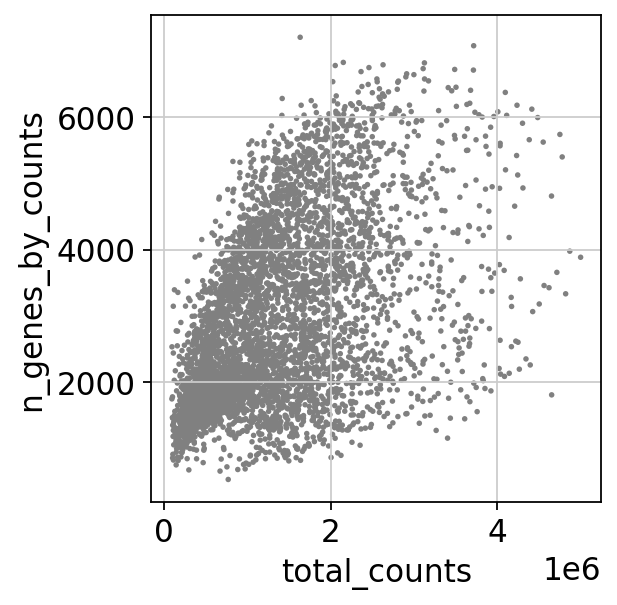

In [9]:
print("Remove cells with very high values for total_counts, possible doublets")

print('Started with: \n', adata)
print_separator()
adata = adata[adata.obs.total_counts < 0.5e7, :]
print('Finished with: \n', adata)

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'],
             jitter=0.4, multi_panel=True)
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

#### Total-count normalize (library-size correct) the data matrix to 10,000 reads per cell, so that counts become comparable among cells.

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

#sc.pl.highly_variable_genes(adata)

adata.raw = adata
adata = adata[:, adata.var.highly_variable]

#Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed. Scale the data to unit variance.
sc.pp.regress_out(adata, ['total_counts'])

#Scale each gene to unit variance. Clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
regressing out ['total_counts']


/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/statsmodels/compat/pandas.py:65: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


    finished (0:00:35)


### PCA 

In [11]:
print("The number of cells and genes going into PCA is: " + str(adata.shape))

The number of cells and genes going into PCA is: (4850, 4949)


In [12]:
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:01)


/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


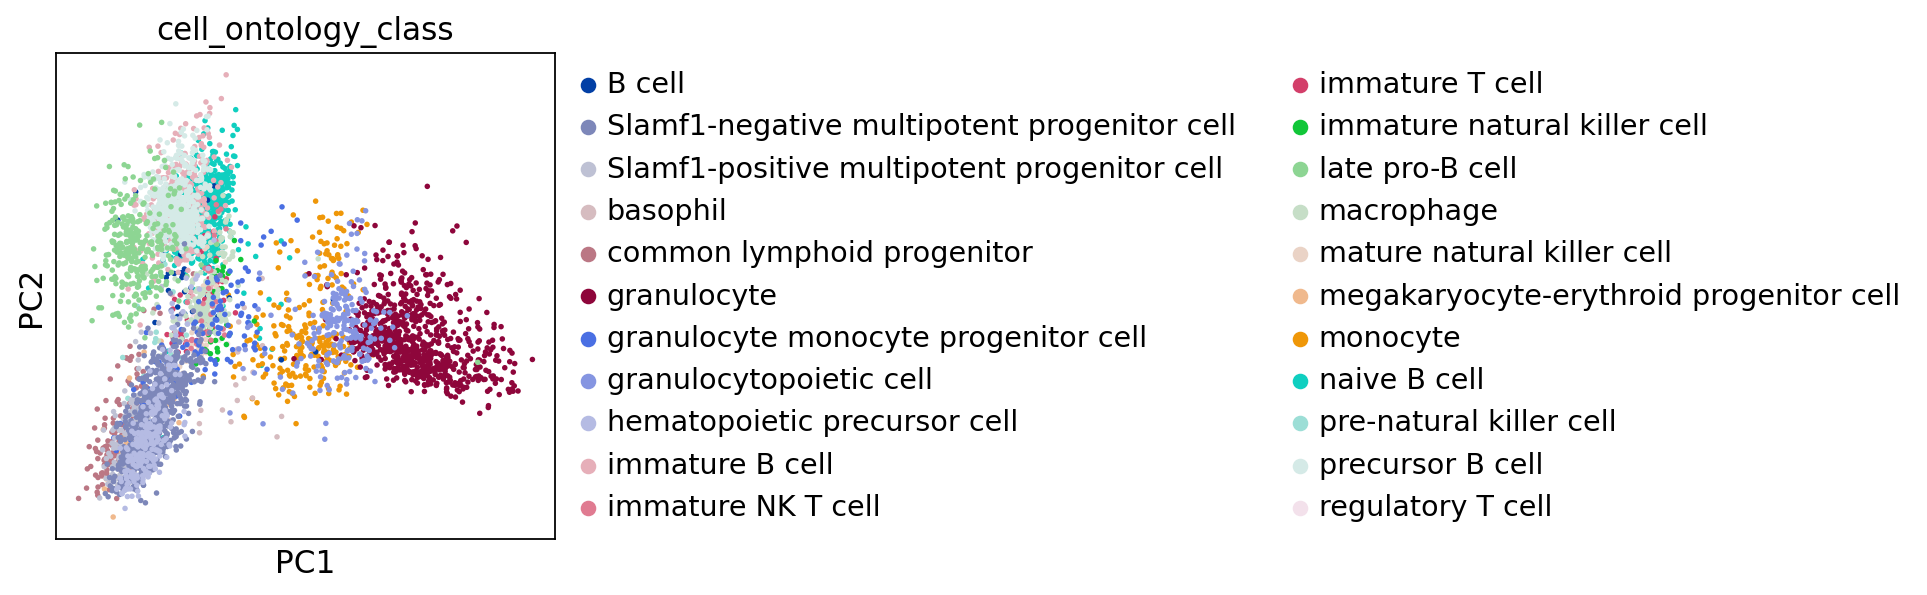

In [13]:
sc.pl.pca(adata, color='cell_ontology_class')

In [14]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)


In [15]:
sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:13)


In [16]:
sc.tl.leiden(adata)

running Leiden clustering
    finished: found 23 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


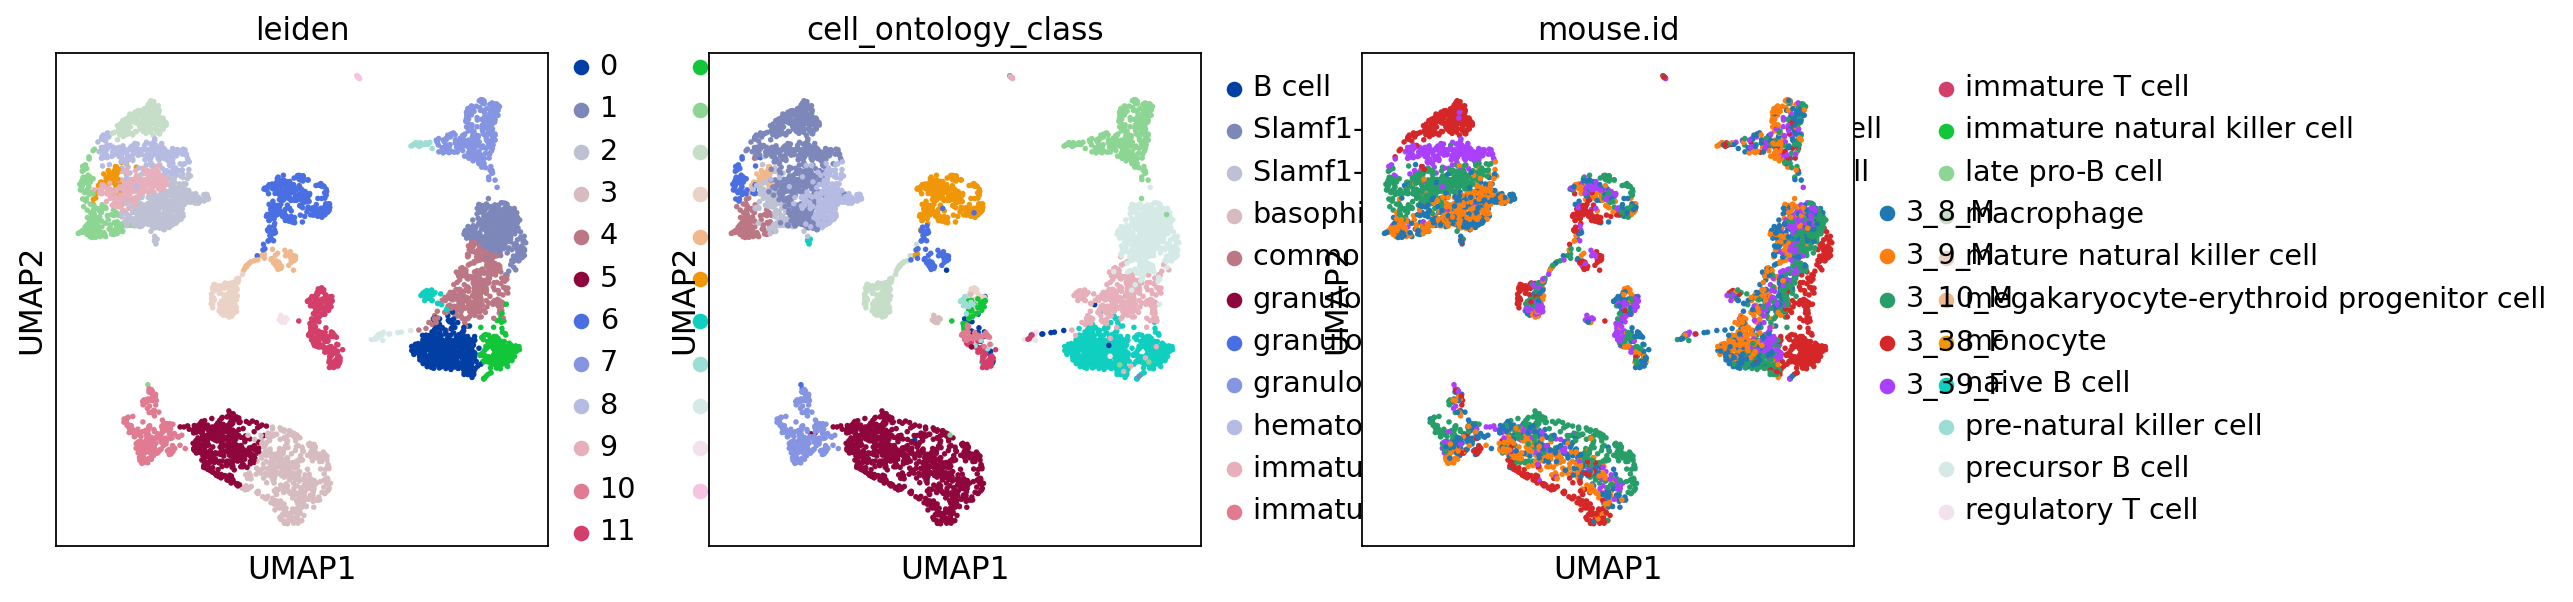

In [17]:
sc.pl.umap(adata, color=['leiden', 'cell_ontology_class', 'mouse.id'])

In [18]:
adata

AnnData object with n_obs × n_vars = 4850 × 4949
    obs: 'cell_ontology_class', 'mouse.id', 'subtissue', 'tissue', 'cell_type', 'cell_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'leiden'
    var: 'gene_name', 'n_cells', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'cell_ontology_class_colors', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'mouse.id_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [19]:
low_dim_rep = adata.obsm['X_pca']
# add cell type labels to the low dimensional representation
low_dim_rep = pd.DataFrame(low_dim_rep)
# add PCA to each column name 
low_dim_rep.columns = ['PCA_' + str(x) for x in low_dim_rep.columns]
low_dim_rep['cell_id'] = adata.obs['cell_id'].values
low_dim_rep['cell_type'] = adata.obs['cell_ontology_class'].values

# Do the same for X_umap 
low_dim_rep_umap = adata.obsm['X_umap']
low_dim_rep_umap = pd.DataFrame(low_dim_rep_umap)
low_dim_rep_umap.columns = ['UMAP_' + str(x) for x in low_dim_rep_umap.columns]
low_dim_rep_umap['cell_id'] = adata.obs['cell_id'].values
low_dim_rep_umap['cell_type'] = adata.obs['cell_ontology_class'].values

In [20]:
# save low dimensional embedding for downstream analysis and Psix input...
output_dir = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMarrow'

# PCA embedding
output_file = os.path.join(output_dir, 'scanpy_pca_embedding.csv')
low_dim_rep.to_csv(output_file, index=True, header=True)
print('Saved PCA low dimensional embedding to {}'.format(output_file))

# UMAP embedding
output_file = os.path.join(output_dir, 'scanpy_umap_embedding.csv')
low_dim_rep_umap.to_csv(output_file, index=True, header=True)
print('Saved UMAP low dimensional embedding to {}'.format(output_file))

Saved PCA low dimensional embedding to /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMarrow/scanpy_pca_embedding.csv
Saved UMAP low dimensional embedding to /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisMarrow/scanpy_umap_embedding.csv
